# **4.4 Model Selection, Underfitting, and Overfitting**
As machine learning scientists, our goal is to discover patterns. But how can we be sure that the model has truly discovered a generalizable pattern, rather than simply memorizing the data? For example, suppose we want to find patterns between patients’ genetic data and their dementia status, where the labels are drawn from the set {dementia, mild cognitive impairment, healthy}. **Since genes can uniquely identify each individual (excluding twins), it is possible to memorize the entire dataset in this task.**<br><br>
We don’t want the model to just say things like, “That’s Bob! I remember him! He has dementia!” The reason is simple: when we deploy the model in the future, it will need to make judgments about patients it has never seen before. **The model will only make effective predictions if it truly discovers a generalizable pattern.**<br><br>
**More formally, our goal is to discover certain patterns that capture the underlying regularities of the population represented by our training set.** If we succeed in doing this, the model will be able to successfully assess risk even for instances it has never encountered before. How to discover patterns that generalize is a fundamental problem in machine learning.<br><br>
The challenge is that when we train a model, we have access to only a small fraction of the data. The largest publicly available image dataset contains about one million images. Most of the time, however, we can only learn from a few thousand or tens of thousands of data samples. In large hospital systems, we might have access to hundreds of thousands of medical records. When we work with a limited sample size, we may encounter a problem where, as more data is collected, we discover that the apparent relationships we previously identified no longer hold true.<br><br>
**The phenomenon in which a model fits the training data more closely than the underlying distribution is called overfitting, and the technique used to counteract overfitting is called regularization.** In previous chapters, some readers may have already observed this phenomenon of overfitting while conducting experiments with the Fashion-MNIST dataset. When adjusting the model architecture or hyperparameters during experiments, you will find that if there are enough neurons, layers, and training iterations, the model can eventually achieve perfect accuracy on the training set, yet the accuracy on the test set decreases.

## **4.4.1 Training Error and Generalization Error**
To further discuss this phenomenon, we need to understand training error and generalization error. **Training error refers to the error calculated by the model on the training dataset. Generalization error refers to the expected error of the model when applied to an infinite number of data samples drawn from the same distribution as the original samples.**<br><br>
**The problem is that we can never accurately calculate the generalization error.** This is because an infinite number of data samples is a hypothetical concept. **In practice, we can only estimate the generalization error by applying the model to an independent test set consisting of randomly selected data samples that did not appear in the training set.**

### **Theory of Statistical Learning**
Since generalization is a fundamental problem in machine learning, many mathematicians and theorists have devoted their careers to developing formal theories that describe this phenomenon. In the eponymous theorem 62, Grivenco and Cantley derived the rate at which the training error converges to the generalization error. In a series of groundbreaking papers, Vapnik and Chervonenkis⁶³ extended this theory to a more general class of functions. This work laid the foundation for statistical learning theory.<br><br>
In the supervised learning scenarios we have discussed so far—and will continue to discuss—we assume that both the training data and the test data are drawn independently from the same distribution. **This is commonly referred to as the independent and identically distributed assumption, which means that the sampling process has no “memory.”** In other words, the correlation between the second and third samples drawn is no stronger than the correlation between the second and the 2 millionth samples drawn.<br><br>
To be an excellent machine learning scientist, one must possess critical thinking skills. Hypotheses are inherently flawed—that is, it is easy to identify scenarios in which they fail. What would happen if we trained a mortality risk prediction model using patient data from the University of California, San Francisco Medical Center and then applied it to patient data from Massachusetts General Hospital? The distributions of these two datasets may not be exactly the same. Furthermore, the sampling process may be time-dependent. For example, when classifying topics on Weibo, the news cycle can introduce temporal dependencies in trending topics, thereby violating the independence assumption.<br><br>
**Sometimes, even if we slightly violate the assumption of independent and identically distributed data, the model will still perform very well.** For example, we have many useful tools that are already being applied in the real world, such as facial recognition, speech recognition, and language translation. **After all, almost all real-world applications involve at least some degree of violation of thethe assumption of independent and identically distributed data.**<br><br>
Certain behaviors that violate the independent and identically distributed assumption are bound to cause problems. For example, suppose we try to train a facial recognition system using only facial data from college students and then attempt to use it to monitor elderly residents in a nursing home. This is unlikely to be effective, because college students often look very different from the elderly.<br><br>
In the following sections, we will discuss the problems arising from violations of the independent and identically distributed assumption. Currently, even if we take the independent and identically distributed assumption for granted, understanding generalization remains a difficult problem. Furthermore, the theoretical foundations capable of explaining the generalization performance of deep neural networks continue to puzzle the greatest scholars in the field of learning theory.<br><br>
When we train a model, we try to find a function that fits the training data as closely as possible. However, if it performs “too well”—to the point where it cannot generalize well to unseen data—this leads to overfitting. This is precisely the situation we want to avoid or control. In deep learning, there are many heuristic techniques designed to prevent overfitting.

### **Model Complexity**
When we have a simple model and a large amount of data, we expect the generalization error to be similar to the training error. When we have a more complex model and fewer samples, we expect the training error to decrease, but the generalization error to increase. What constitutes model complexity is a complex issue. Whether a model generalizes well depends on many factors. For example, a model with more parameters may be considered more complex, and a model with a wider range of parameter values may also be more complex. Generally, for neural networks, we consider models that require more training iterations to be more complex, while models that require early stopping (i.e., fewer training iterations) are less complex.<br><br>
It is difficult to compare the complexity of models that belong to fundamentally different categories (such as decision trees and neural networks). For now, a simple rule of thumb is quite useful: **statisticians believe that models capable of easily explaining any given fact are complex, whereas models with limited expressive power that still explain the data well may have greater practical utility.** Philosophically, this is closely related to Popper’s criterion of falsifiability for scientific theories: **if a theory fits the data and there are specific tests that can be used to prove it wrong, then it is a good theory. This is important because all statistical estimates are based on a posteriori induction. In other words, we make estimates after observing the facts, and are therefore susceptible to the correlation fallacy.**<br><br>
In this section, to provide some intuitive insights, we will focus on several factors that tend to affect model generalization.
  1. **The number of adjustable parameters. When the number of adjustable parameters (sometimes referred to as degrees of freedom) is large, models tend to overfit more easily.**
2. **The values used for the parameters. When the range of weight values is large, the model may be more prone to overfitting.**
3. **The number of training samples. Even a very simple model can easily overfit a dataset containing only one or two samples. On the other hand, overfitting a dataset with millions of samples requires an extremely flexible model.**

## **4.4.2 Model Selection**
**In machine learning, we typically select a final model after evaluating several candidate models. This process is called model selection. Sometimes, the models being compared are fundamentally different (for example, decision trees and linear models). Other times, we need to compare models of the same type under different hyperparameter settings.**<br><br>
For example, when training a multi-layer perceptron model, we may want to compare models with different numbers of hidden layers, different numbers of hidden units, and different combinations of activation functions. **To determine the best model among the candidates, we typically use a validation set.**


### **Validation Set**
**As a general rule, we should avoid using the test set until we have finalized all the hyperparameters. If we use the test data during the model selection process, we run the risk of overfitting the test data—which would be a major problem. If we overfit the training data, we can still detect it by evaluating the model on the test data.** But if we overfit the test data, how would we even know?<br><br>
**Therefore, we must not rely on test data for model selection. However, we also cannot rely solely on training data to select a model, because we cannot estimate the generalization error of the training data.**<br><br>
In practice, the situation becomes more complicated. **Although, ideally, we would use the test data only once—to evaluate the best model or compare the performance of several models—in reality, test data is rarely discarded after a single use.** We rarely have enough data to use a completely new test set for each round of experiments.<br><br>
**A common approach to addressing this issue is to divide our data into three parts: in addition to the training and test datasets, we include a validation dataset, also known as a validation set. However, in reality, the distinction between validation data and test data is alarmingly blurred. Unless otherwise specified, in the experiments in this book, we are actually using datasets that should more accurately be referred to as training data and validation data, and there is no true test dataset. Therefore, the accuracy reported for each experiment in the book is the validation set accuracy, not the test set accuracy.**

### **K-fold Cross-Validation**
When training data is scarce, we may not even be able to provide enough data to form a suitable validation set. **A popular solution to this problem is to use K-fold cross-validation. Here, the original training data is divided into K non-overlapping subsets. The model is then trained and validated K times, with training performed on K−1 subsets each time and validation performed on the remaining subset (the one not used for training in that round). Finally, the training and validation errors are estimated by averaging the results of the K experiments.**

## **4.4.3 Underfitting or Overfitting?**
When comparing training and validation errors, we should be aware of two common scenarios. **First, we should pay attention to situations where both the training error and the validation error are high, but there is only a slight difference between them. If the model cannot reduce the training error, this may indicate that the model is too simple (i.e., lacks expressive power) to capture the patterns it is trying to learn. Furthermore, since the generalization error between our training and validation errors is small, we have reason to believe that a more complex model could reduce the training error. This phenomenon is known as underfitting.**<br><br>
**On the other hand, we should be cautious when our training error is significantly lower than the validation error, as this indicates severe overfitting. Note that overfitting is not always a bad thing. Especially in the field of deep learning, it is well known that the best predictive models often perform much better on the training data than on the held-out (validation) data. Ultimately, we are usually more concerned with the validation error than with the difference between the training error and the validation error.**

### **Model Complexity**
To illustrate some classic intuitions regarding overfitting and model complexity, we present an example involving polynomials. Given training data consisting of a single feature x and corresponding real-valued labels y, we seek to find a polynomial of degree d to estimate the labels y.
##### **(4.4.1)**
$$\hat{y}=\sum\limits_{i=0}^{d}x^{i}w_{i}$$
This is simply a linear regression problem, where our features are given by the powers of $x$, the model weights are given by $w_i$, and the bias is given by $w_0$ (since $x^0 = 1$ for all $x$). Since this is simply a linear regression problem, we can use the mean squared error as our loss function.<br><br>
Higher-order polynomial functions are much more complex than lower-order polynomial functions. Higher-order polynomials have more parameters and offer a wider range of model function choices. **Therefore, given a fixed training dataset, the training error of a higher-order polynomial function should always be lower (or, at worst, equal to) that of a lower-order polynomial function. In fact, when the data samples contain different values of x, a polynomial function whose degree equals the number of data samples can perfectly fit the training set.** In [Figure 4.4.1](#fig-414), we provide a visual illustration of the relationship between the degree of a polynomial and underfitting versus overfitting.
##### **Fig(4.4.1)**
![MLP](../../images/picture4_4_1.png)<br><br>

### **Dataset Size**
Another important factor is the size of the dataset. **The fewer samples in the training dataset, the more likely we are to overfit—and the more severe the overfitting will be. As the amount of training data increases, the generalization error typically decreases. Furthermore, in general, having more data does no harm.** For a given task and data distribution, there is usually a relationship between model complexity and dataset size. Given more data, we may attempt to fit a more complex model. The ability to fit more complex models can be beneficial. If there is insufficient data, a simple model may be more useful. For many tasks, deep learning outperforms linear models only when there are thousands of training samples. To a certain extent, the current vitality of deep learning is attributable to cheap storage, connected devices, and the massive datasets generated by the digital economy.

## **4.4.4 Polynomial Regression**
We can now explore these concepts through polynomial fitting.

In [8]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

### **Generate a Dataset**
Given x, we will use the following third-degree polynomial to generate labels for the training and test data:
##### (4.4.2)
$$
y=5+1.2x-3.4\frac{x^{2}}{2!}+5.6\frac{x^{3}}{3!}+\epsilon \: where\: \epsilon\: \sim \mathcal{N}(0, 0.1^{2})
$$
The noise term $\epsilon$ follows a normal distribution with a mean of 0 and a standard deviation of 0.1. **During the optimization process, we generally want to avoid very large gradient or loss values.** This is why we adjust the features from $x^i$ to $\frac{x^i}{i!}$—to avoid particularly large exponential values caused by large values of $i$. We will generate 100 samples each for the training set and the test set.

In [9]:
max_degree = 20 # Maximum Degree of a Polynomial
n_train, n_test = 100, 100 # Size of the training and test datasets
true_w = np.zeros(max_degree) # Allocate a large amount of space
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1) # gamma(n)=(n-1)!
# Dimensions of `labels`: (n_train + n_test,)
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

Similarly, the polynomials stored in `poly_features` are rescaled by the gamma function, where $Γ(n) = (n−1)!$. Looking at the first two samples from the generated dataset, the first value is the constant feature corresponding to the bias.

In [10]:
# Converting a NumPy ndarray to a tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype= torch.float32) for x in [true_w, features, poly_features, labels]]

In [11]:
features[:2], poly_features[:2, :], labels[:2]

(tensor([[ 0.4205],
         [-1.2158]]),
 tensor([[ 1.0000e+00,  4.2048e-01,  8.8403e-02,  1.2391e-02,  1.3025e-03,
           1.0954e-04,  7.6763e-06,  4.6111e-07,  2.4236e-08,  1.1323e-09,
           4.7612e-11,  1.8200e-12,  6.3772e-14,  2.0627e-15,  6.1952e-17,
           1.7367e-18,  4.5639e-20,  1.1289e-21,  2.6370e-23,  5.8359e-25],
         [ 1.0000e+00, -1.2158e+00,  7.3903e-01, -2.9949e-01,  9.1027e-02,
          -2.2133e-02,  4.4848e-03, -7.7892e-04,  1.1837e-04, -1.5990e-05,
           1.9440e-06, -2.1486e-07,  2.1768e-08, -2.0357e-09,  1.7678e-10,
          -1.4328e-11,  1.0887e-12, -7.7860e-14,  5.2588e-15, -3.3650e-16]]),
 tensor([ 5.1995, -0.6354]))

### **Train and test the model**
First, let's implement a function to evaluate the model's loss on a given dataset.

In [12]:
def evaluate_loss(net, data_iter, loss): #@save
    """Evaluate the model's loss on a given dataset"""
    metric = d2l.Accumulator(2) # Total losses, sample size
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

Now define the training function.

In [13]:
def train(train_features, test_features, train_labels, test_labels, num_epochs=400):
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    # We do not set a bias, because we have already implemented it in the polynomial.
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_features.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1, 1)), batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)), batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log', xlim=[1, num_epochs], ylim=[1e-3, 1e2], legend=['train', 'test'])
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 ==0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss), evaluate_loss(net, test_iter, loss)))

    print('weight:', net[0].weight.data.numpy())

### **Third-Order Polynomial Function Fitting (Normal)**
We will first use a third-order polynomial function, which has the same order as the data-generating function. The results show that this model effectively reduces both the training loss and the testing loss. The learned model parameters are also close to the true values, $w = [5, 1.2, −3.4, 5.6]$.

weight: [[ 5.0252366  1.2347317 -3.3876076  5.5332327]]


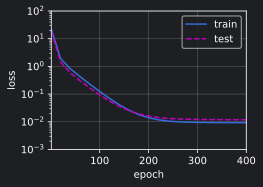

In [14]:
# Select the top 4 dimensions from the polynomial features, namely 1, x, x²/2!, and x³/3!
train(poly_features[:n_train, :4], poly_features[n_train:, :4], labels[:n_train], labels[n_train:])

### **Linear Function Fitting (Underfitting)**
Let’s take another look at linear function fitting; it is relatively difficult to reduce the training loss for this model. Even after the final iteration cycle is complete, the training loss remains high. **Linear models tend to underfit when used to fit nonlinear patterns, such as the third-order polynomial function shown here.**

weight: [[3.5414557 3.5222805]]


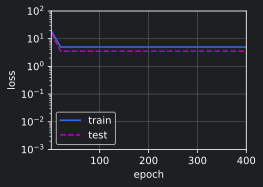

In [15]:
# Select the top 2 dimensions from the polynomial features, namely 1 and x
train(poly_features[:n_train, :2], poly_features[n_train:, :2], labels[:n_train], labels[n_train:])

### **High-Order Polynomial Function Fitting (Overfitting)**
Now, let’s try training the model using a polynomial of too high a degree. **In this case, there isn’t enough data for the model to learn that the higher-order coefficients should be close to zero. As a result, this overly complex model is easily influenced by noise in the training data. Although the training loss can be effectively reduced, the test loss remains high**. The results show that the complex model causes the data to overfit.

weight: [[ 5.0160103   1.312909   -3.3179185   5.0711527  -0.32053986  1.4620582
   0.03998452  0.07719937  0.19190441  0.05771716 -0.05058496 -0.00726369
   0.08778866  0.01059848 -0.0150348   0.0923996   0.15275733 -0.12153737
   0.09213519  0.09428206]]


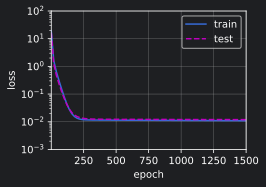

In [16]:
# Select all dimensions from the polynomial features
train(poly_features[:n_train, :], poly_features[n_train:, :], labels[:n_train], labels[n_train:], num_epochs=1500)

## **Summary**
  * **Underfitting occurs when a model can no longer reduce the training error. Overfitting occurs when the training error is significantly smaller than the validation error**.
  * **Since it is not possible to estimate the generalization error based on the training error, simply minimizing the training error does not necessarily lead to a reduction in the generalization error. In machine learning, it is important to prevent overfitting—that is, to prevent the generalization error from becoming too large**.
  * Validation sets can be used for model selection, but they should not be used too indiscriminately.
  * We should choose a model with appropriate complexity and avoid using an insufficient number of training samples.